# Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("flights_new.csv")

# Preview
print(df.head())
print(df.info())

   id  year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
0   0  2013      1    1     517.0             515        2.0     830.0   
1   1  2013      1    1     533.0             529        4.0     850.0   
2   2  2013      1    1     542.0             540        2.0     923.0   
3   3  2013      1    1     544.0             545       -1.0    1004.0   
4   4  2013      1    1     554.0             600       -6.0     812.0   

   sched_arr_time  arr_delay  ... distance  hour minute            time_hour  \
0             819       11.0  ...     1400     5     15  2013-01-01 05:00:00   
1             830       20.0  ...     1416     5     29  2013-01-01 05:00:00   
2             850       33.0  ...     1089     5     40  2013-01-01 05:00:00   
3            1022      -18.0  ...     1576     5     45  2013-01-01 05:00:00   
4             837      -25.0  ...      762     6      0  2013-01-01 06:00:00   

                     name  flight_date  day_of_week    route  cancelled  \

# Top Airlines

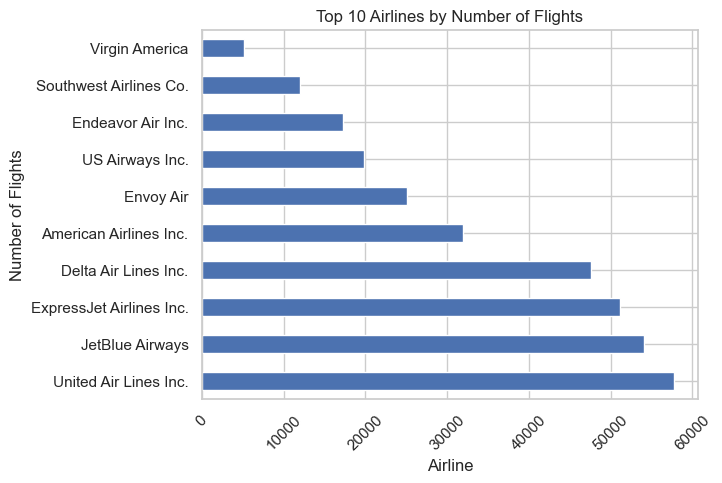

In [3]:
top_airlines = df['name'].value_counts().head(10)

plt.figure()
top_airlines.plot(kind='barh')
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

# Top Routes

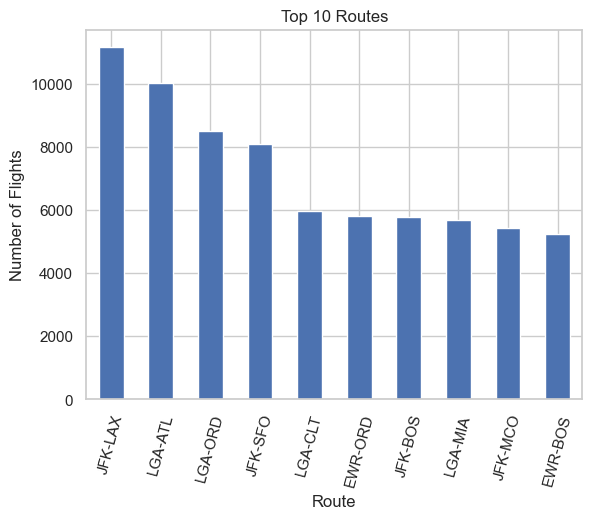

In [4]:
#df['Route'] = df['Origin'] + " - " + df['Dest']
top_routes = df['route'].value_counts().head(10)

plt.figure()
top_routes.plot(kind='bar')
plt.title("Top 10 Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=75)
plt.show()

# Busiest Months (Line Plot)

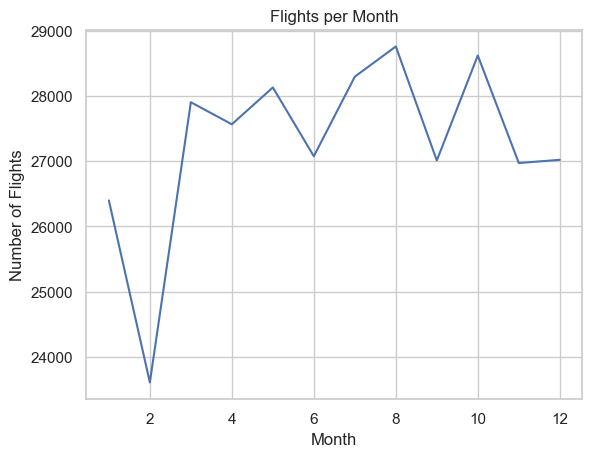

In [5]:
monthly_flights = df['month'].value_counts().sort_index()

plt.figure()
plt.plot(monthly_flights.index, monthly_flights.values)
plt.title("Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

# Flights by Day of Week

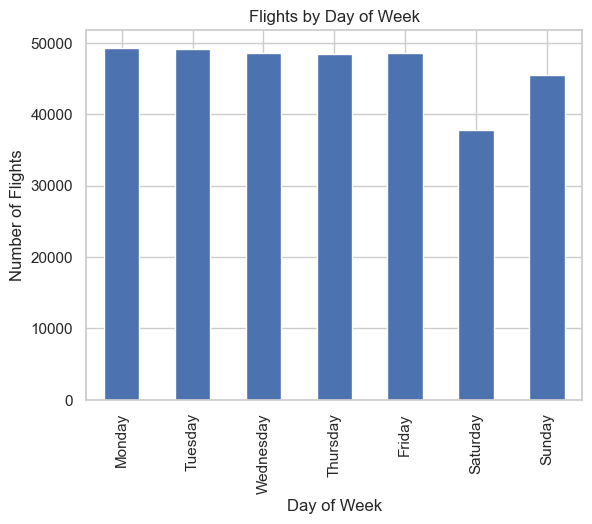

In [8]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_flights = df['day_of_week'].value_counts().reindex(day_order)

plt.figure()
day_flights.plot(kind='bar')
plt.title("Flights by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")
plt.show()

# Line Plot (Trend Style)

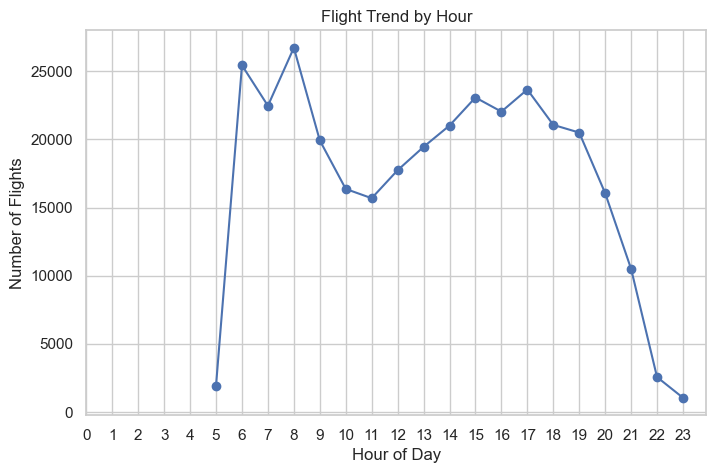

In [9]:
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.plot(hour_counts.index, hour_counts.values, marker='o')

plt.title("Flight Trend by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.xticks(range(0,24))
plt.show()

# Flights by Airport (Bar Chart)

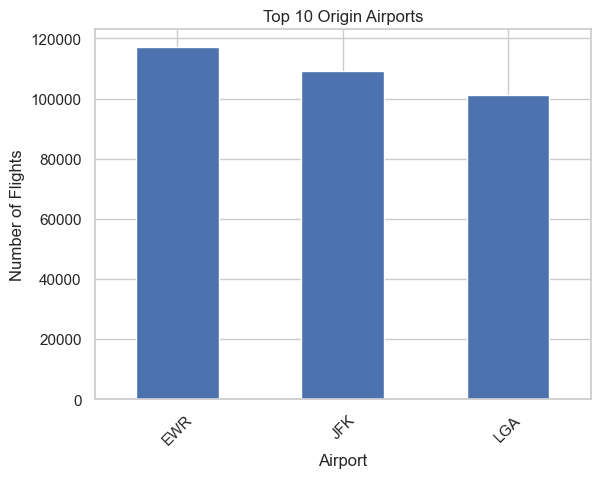

In [11]:
top_airports = df['origin'].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top 10 Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

# Average Arrival Delay by Airline

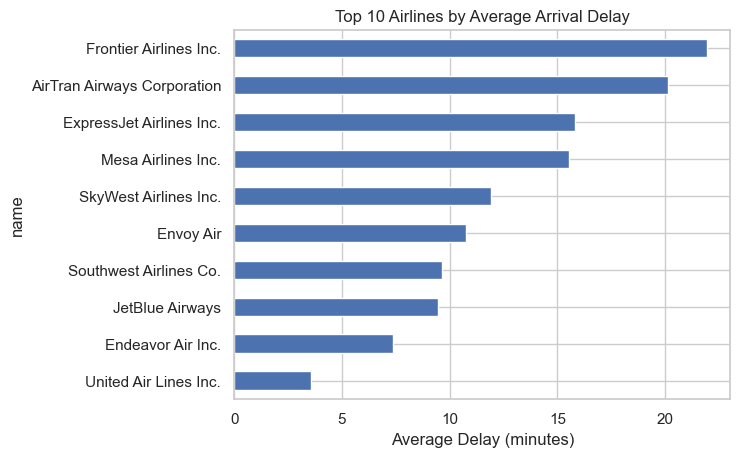

In [12]:
avg_delay_airline = (
    df.groupby('name')['arr_delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
avg_delay_airline.sort_values().plot(kind='barh')
plt.title("Top 10 Airlines by Average Arrival Delay")
plt.xlabel("Average_Delay (minutes)")
plt.show()

# Departure Delay vs Arrival Delay (Scatter Plot)

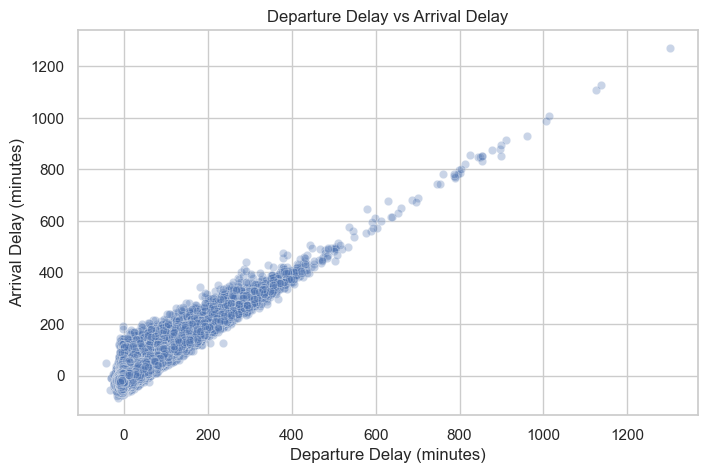

Correlation: 0.91


In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='dep_delay',
    y='arr_delay',
    data=df,
    alpha=0.3
)

plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

# Correlation value
print("Correlation:",
      round(df['dep_delay'].corr(df['arr_delay']), 2))

# Airline vs Average Departure Delay (Bar Chart)

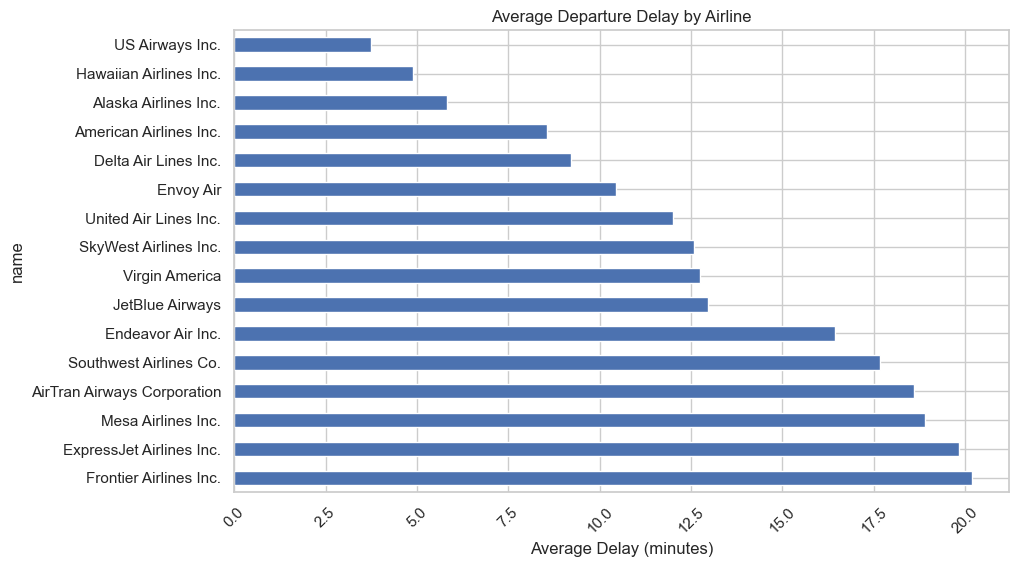

In [16]:
airline_delay = (
    df.groupby('name')['dep_delay']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
airline_delay.plot(kind='barh')

plt.title("Average Departure Delay by Airline")
plt.xlabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

# Hour of Day vs Average Departure Delay (Line Plot)

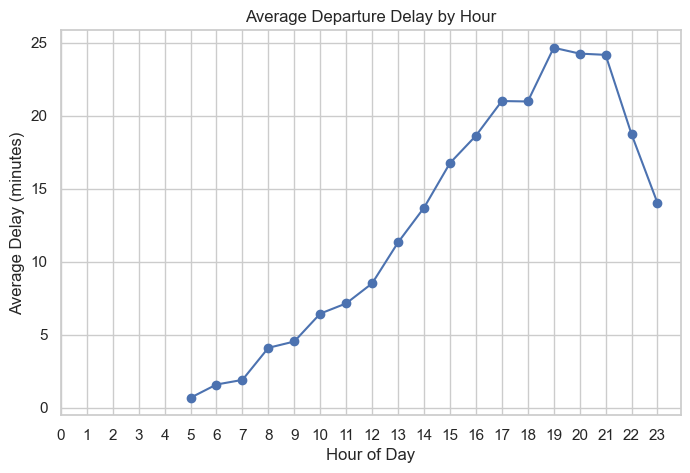

In [17]:
hour_delay = (
    df.groupby('hour')['dep_delay']
    .mean()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.plot(hour_delay.index, hour_delay.values, marker='o')

plt.title("Average Departure Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.xticks(range(0,24))
plt.show()

# Airport vs Average Departure Delay (Horizontal Bar)

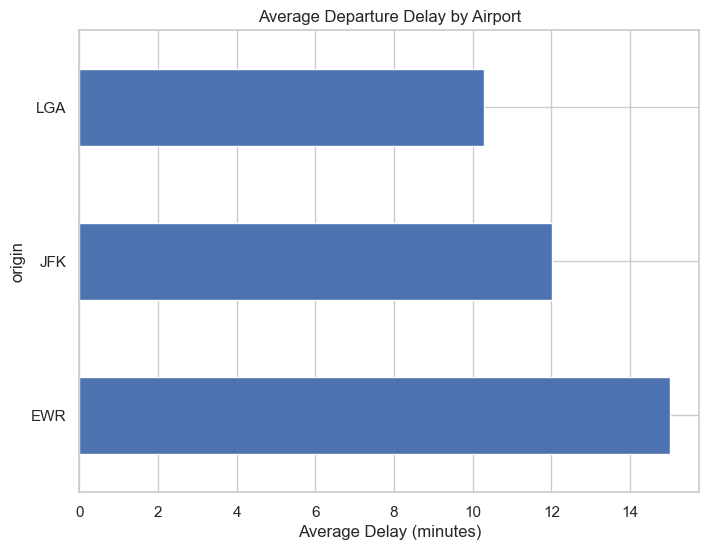

In [18]:
airport_delay = (
    df.groupby('origin')['dep_delay']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))
airport_delay.plot(kind='barh')

plt.title("Average Departure Delay by Airport")
plt.xlabel("Average Delay (minutes)")
plt.show()

# Airport vs Hour Delay — Heatmap

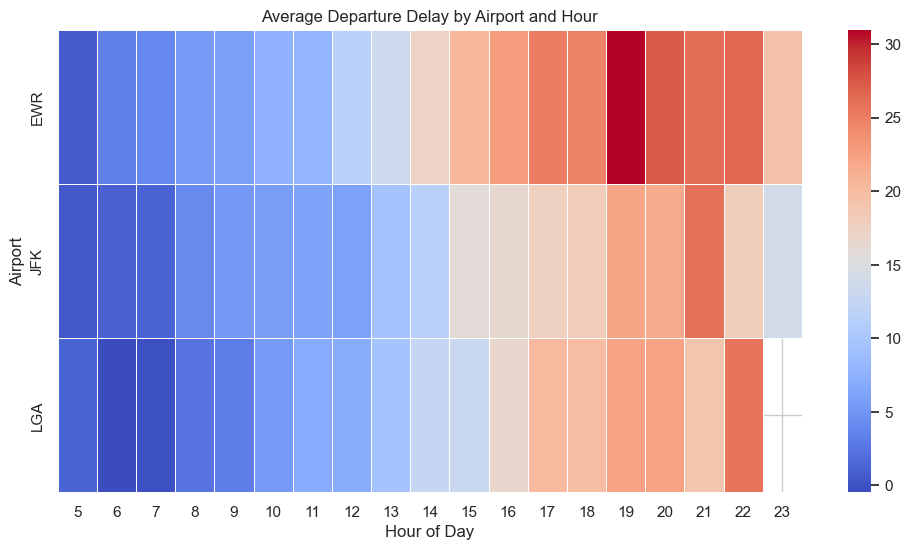

In [19]:
# Create pivot table
pivot_table = df.pivot_table(
    values='dep_delay',     # or 'arr_delay'
    index='origin',         # Airport
    columns='hour',         # Hour of day
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Average Departure Delay by Airport and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Airport")
plt.show()